<a href="https://colab.research.google.com/github/Deepanshu-8126/Numpy-/blob/main/NumPy_Part2_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 NumPy — Part 2: Advanced
### Complete Revision Notebook | Data Science
---
> **Prerequisites:** Part 1 completed ✅
>
> **What's in Part 2?**
> - Statistical Functions (most used in Data Science)
> - Linear Algebra (used in ML algorithms)
> - Advanced Random Module
> - Advanced Indexing Tricks
> - Structured Arrays
> - Performance Tips
> - Real Data Science Use Cases


## ⚙️ Setup — Run This First!

In [2]:
#h
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Setup complete!")
print("NumPy version:", np.__version__)

Setup complete!
NumPy version: 2.0.2


---
# 📌 Topic 11 — Statistical Functions
**Most used in Data Science EDA (Exploratory Data Analysis)**

These functions help you understand your data before building any model.
Always run these first on any new dataset!


In [4]:
# ── Topic 11A: Basic Statistics──

np.random.seed(42)
data = np.random.randint(30, 100, 50)
print("Data (50 student marks):")
print(data)
print()

# Central Tendency
print("=" * 40)
print("CENTRAL TENDENCY")
print("=" * 40)
print("Mean (average):", np.mean(data).round(2))
# sum of all / count

print("Median (middle value):", np.median(data))
# middle value when sorted
# less affected by outliers than mean!

# Mode is not in NumPy — use scipy
from scipy import stats
mode_result = stats.mode(data, keepdims=True)
print("Mode (most frequent):", mode_result.mode[0])

print()

# Spread
print("=" * 40)
print("SPREAD / VARIABILITY")
print("=" * 40)
print("Min:", np.min(data))
print("Max:", np.max(data))
print("Range:", np.max(data) - np.min(data))
print("Std deviation:", np.std(data).round(2))
# std = average distance from mean
# small std = data close together
# big std = data spread out

print("Variance:", np.var(data).round(2))
# variance = std squared

Data (50 student marks):
[81 44 90 50 53 32 51 82 31 59 67 31 93 89 50 62 87 51 78 88 71 89 44 91
 91 76 91 80 84 93 32 80 36 50 68 47 33 89 43 38 82 31 89 73 37 76 64 65
 79 33]

CENTRAL TENDENCY
Mean (average): 64.48
Median (middle value): 67.5
Mode (most frequent): 89

SPREAD / VARIABILITY
Min: 31
Max: 93
Range: 62
Std deviation: 21.39
Variance: 457.69


In [5]:
# ── Topic 11B: Percentiles & Quartiles ──

np.random.seed(42)
data = np.random.randint(30, 100, 50)

print("PERCENTILES & QUARTILES")
print("=" * 40)

# percentile = what value is at x% of sorted data
print("25th percentile (Q1):", np.percentile(data, 25))
print("50th percentile (Q2/Median):", np.percentile(data, 50))
print("75th percentile (Q3):", np.percentile(data, 75))

# IQR = Q3 - Q1 (middle 50% of data)
Q1  = np.percentile(data, 25)
Q3  = np.percentile(data, 75)
IQR = Q3 - Q1
print("IQR (Q3-Q1):", IQR)
# IQR is used to find outliers!

print()

# Outlier detection using IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.1f}")
print(f"Upper bound: {upper_bound:.1f}")

outliers = data[(data < lower_bound) | (data > upper_bound)]
print("Outliers:", outliers)
# This is the standard box plot outlier method!

print()

# Summary (like pandas describe())
print("FULL SUMMARY")
print("=" * 40)
percentiles = [0, 25, 50, 75, 100]
for p in percentiles:
    print(f"  {p}th percentile: {np.percentile(data, p):.1f}")
print(f"  Mean: {np.mean(data):.1f}")
print(f"  Std:  {np.std(data):.1f}")

print()
print("✅ Topic 11 Done!")
print("Key: mean/median/std/percentile/IQR — run these on every new dataset!")

PERCENTILES & QUARTILES
25th percentile (Q1): 44.75
50th percentile (Q2/Median): 67.5
75th percentile (Q3): 83.5
IQR (Q3-Q1): 38.75

Lower bound: -13.4
Upper bound: 141.6
Outliers: []

FULL SUMMARY
  0th percentile: 31.0
  25th percentile: 44.8
  50th percentile: 67.5
  75th percentile: 83.5
  100th percentile: 93.0
  Mean: 64.5
  Std:  21.4

✅ Topic 11 Done!
Key: mean/median/std/percentile/IQR — run these on every new dataset!


---
# 📌 Topic 12 — Advanced Random Module
**Why important?**
- Creating synthetic/fake data for testing
- Randomly splitting train/test data
- Simulations and probability experiments
- Data augmentation in Deep Learning


RANDOM NUMBER GENERATION
Uniform (0 to 10): [3.75 9.51 7.32 5.99 1.56]
Normal (mean=50, std=10): [52.8 60.1 44.2 44.7 44.3 40.8 23.9 59.5 58.2 34.8]
Binomial (n=10, p=0.5): [3 4 4 5 6]
Poisson (lam=5): [3 3 6 3 9]



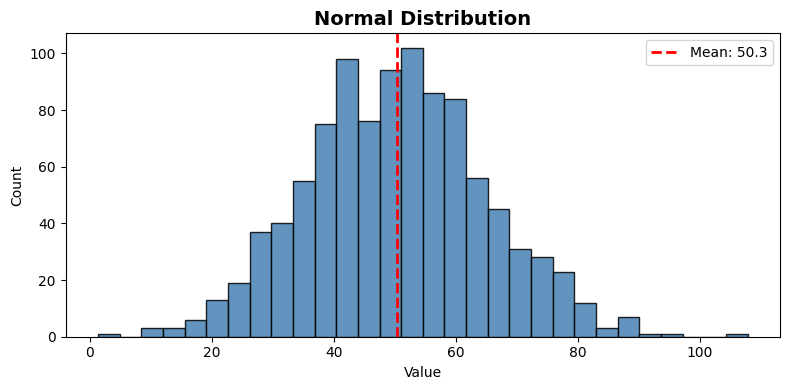

In [6]:
# ── Topic 12A: Random Distributions ──

np.random.seed(42)

print("RANDOM NUMBER GENERATION")
print("=" * 40)

# Uniform distribution (all values equally likely)
uniform = np.random.uniform(low=0, high=10, size=5)
print("Uniform (0 to 10):", uniform.round(2))

# Normal / Gaussian distribution (bell curve)
normal = np.random.normal(loc=50, scale=10, size=10)
# loc = mean (center of bell), scale = std deviation
print("Normal (mean=50, std=10):", normal.round(1))

# Binomial (success/fail experiments)
# Like: flip a coin 10 times, what's the outcome?
binomial = np.random.binomial(n=10, p=0.5, size=5)
# n = number of trials, p = probability of success
print("Binomial (n=10, p=0.5):", binomial)

# Poisson (rare events)
# Like: how many customers arrive per hour?
poisson = np.random.poisson(lam=5, size=5)
# lam = average rate
print("Poisson (lam=5):", poisson)

print()

# Visualize normal distribution
np.random.seed(42)
data = np.random.normal(50, 15, 1000)

plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
plt.axvline(np.mean(data), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(data):.1f}')
plt.title("Normal Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── Topic 12B: Random Sampling & Shuffling ──

np.random.seed(42)

# choice = randomly pick elements from array
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
print("Original:", arr)
print()

# Pick 3 random elements (without replacement)
picked = np.random.choice(arr, size=3, replace=False)
print("Random choice (no repeat):", picked)

# Pick 5 with replacement (can repeat)
picked2 = np.random.choice(arr, size=5, replace=True)
print("Random choice (with repeat):", picked2)

print()

# shuffle = shuffle IN-PLACE (changes the original!)
arr2 = np.arange(1, 11)
print("Before shuffle:", arr2)
np.random.shuffle(arr2)
print("After shuffle:", arr2)
# Warning: shuffle changes the original array!

print()

# Train-Test Split using random
data = np.arange(1, 101)  # 100 samples
np.random.shuffle(data)

split = int(0.8 * len(data))  # 80% train, 20% test
train = data[:split]
test  = data[split:]
print(f"Total: {len(data)} | Train: {len(train)} | Test: {len(test)}")
print("Train (first 5):", train[:5])
print("Test  (first 5):", test[:5])

print()
print("✅ Topic 12 Done!")
print("Key: normal/uniform/binomial | choice() | shuffle() | train-test split")

Original: [ 10  20  30  40  50  60  70  80  90 100]

Random choice (no repeat): [90 20 60]
Random choice (with repeat): [30 70 80 50 40]

Before shuffle: [ 1  2  3  4  5  6  7  8  9 10]
After shuffle: [ 1  9  7  4  2  5  6  3 10  8]

Total: 100 | Train: 80 | Test: 20
Train (first 5): [19 43 37 77 54]
Test  (first 5): [51 84 47 85 62]

✅ Topic 12 Done!
Key: normal/uniform/binomial | choice() | shuffle() | train-test split


---
# 📌 Topic 13 — Linear Algebra
**Why important?**
- Neural networks use matrix multiplication
- PCA (dimensionality reduction) uses eigenvalues
- Linear Regression uses matrix math
- Every ML algorithm has linear algebra under the hood!


In [8]:
# ── Topic 13A: Matrix Operations ──

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

print("Matrix A:")
print(A)
print("Matrix B:")
print(B)
print()

# Element-wise multiplication (NOT matrix multiplication)
print("A * B (element-wise):")
print(A * B)
# [1*5, 2*6]   [5, 12]
# [3*7, 4*8] = [21, 32]

print()

# Matrix multiplication (dot product)
print("A @ B (matrix multiplication):")
print(A @ B)
# This is how neural networks work!
# A @ B = [[1*5+2*7, 1*6+2*8], [3*5+4*7, 3*6+4*8]]
#       = [[19, 22], [43, 50]]
# Also: np.dot(A, B) gives same result

print()
print("np.dot(A, B):")
print(np.dot(A, B))

print()

# Transpose = flip rows and columns
print("A.T (transpose):")
print(A.T)
# Row 0 becomes Col 0, Row 1 becomes Col 1
# (1,2) row → (1,3) column

Matrix A:
[[1 2]
 [3 4]]
Matrix B:
[[5 6]
 [7 8]]

A * B (element-wise):
[[ 5 12]
 [21 32]]

A @ B (matrix multiplication):
[[19 22]
 [43 50]]

np.dot(A, B):
[[19 22]
 [43 50]]

A.T (transpose):
[[1 3]
 [2 4]]


In [9]:
# ── Topic 13B: np.linalg functions ──

A = np.array([[1, 2],
              [3, 4]], dtype=float)
print("Matrix A:")
print(A)
print()

# Determinant
det = np.linalg.det(A)
print("Determinant:", det.round(2))
# det = 1*4 - 2*3 = -2
# If det=0, matrix has no inverse!

# Inverse
inv = np.linalg.inv(A)
print("Inverse of A:")
print(inv.round(3))
# A @ inv(A) = Identity matrix

# Verify: A * A_inv should give identity
print("A @ inv(A) (should be identity):")
print((A @ inv).round(2))

print()

# Eigenvalues and Eigenvectors (used in PCA!)
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:", eigenvalues.round(3))
print("Eigenvectors:")
print(eigenvectors.round(3))
# PCA finds directions of maximum variance using eigenvalues!

print()

# Solve linear equations (Ax = b)
# Solve: 2x + y = 5
#        x + 3y = 10
A_eq = np.array([[2, 1],
                 [1, 3]])
b_eq = np.array([5, 10])
x = np.linalg.solve(A_eq, b_eq)
print("Solution to linear equations:")
print(f"x = {x[0]:.2f}, y = {x[1]:.2f}")

print()
print("✅ Topic 13 Done!")
print("Key: @ = matrix multiply | .T = transpose | linalg.det/inv/eig/solve")

Matrix A:
[[1. 2.]
 [3. 4.]]

Determinant: -2.0
Inverse of A:
[[-2.   1. ]
 [ 1.5 -0.5]]
A @ inv(A) (should be identity):
[[1. 0.]
 [0. 1.]]

Eigenvalues: [-0.372  5.372]
Eigenvectors:
[[-0.825 -0.416]
 [ 0.566 -0.909]]

Solution to linear equations:
x = 1.00, y = 3.00

✅ Topic 13 Done!
Key: @ = matrix multiply | .T = transpose | linalg.det/inv/eig/solve


---
# 📌 Topic 14 — Advanced Indexing Tricks
**These tricks save a lot of time in Data Science!**
- Conditional selection
- Multi-condition filtering
- Replacing values
- Masking


In [10]:
# ── Topic 14A: Advanced Boolean Indexing ──

np.random.seed(42)
marks = np.random.randint(30, 100, 20)
print("Student marks:", marks)
print()

# Multiple conditions
# & = AND | | = OR | ~ = NOT
pass_marks = marks[(marks >= 50) & (marks <= 80)]
print("Marks between 50 and 80:", pass_marks)

fail_marks = marks[marks < 40]
print("Fail marks (<40):", fail_marks)

extreme = marks[(marks < 40) | (marks > 90)]
print("Extreme marks (<40 or >90):", extreme)

not_average = marks[~((marks >= 50) & (marks <= 70))]
print("Not average (~ means NOT):", not_average)

print()

# Count how many satisfy condition
print("Number of students who passed:", np.sum(marks >= 50))
print("Pass percentage:", f"{np.mean(marks >= 50) * 100:.1f}%")
# np.mean on boolean = fraction of True values!

Student marks: [81 44 90 50 53 32 51 82 31 59 67 31 93 89 50 62 87 51 78 88]

Marks between 50 and 80: [50 53 51 59 67 50 62 51 78]
Fail marks (<40): [32 31 31]
Extreme marks (<40 or >90): [32 31 31 93]
Not average (~ means NOT): [81 44 90 32 82 31 31 93 89 87 78 88]

Number of students who passed: 16
Pass percentage: 80.0%


In [11]:
# ── Topic 14B: np.where for Replacing Values ──

np.random.seed(42)
scores = np.random.randint(20, 100, 15)
print("Scores:", scores)
print()

# Replace values based on condition
# np.where(condition, value_if_true, value_if_false)
grades = np.where(scores >= 80, "A",
         np.where(scores >= 60, "B",
         np.where(scores >= 40, "C", "F")))
print("Grades:")
for s, g in zip(scores, grades):
    print(f"  Score: {s:3d} → Grade: {g}")

print()

# Replace values in numeric array
# Set all values > 90 to 90 (capping)
capped = np.where(scores > 90, 90, scores)
print("Original:", scores)
print("Capped at 90:", capped)

print()

# clip = cap values between min and max (easier than where!)
clipped = np.clip(scores, 40, 90)
# all values below 40 become 40
# all values above 90 become 90
print("Clipped (40-90):", clipped)

print()
print("✅ Topic 14A-B Done!")

Scores: [71 34 91 80 40 94 94 43 22 41 72 21 49 57 21]

Grades:
  Score:  71 → Grade: B
  Score:  34 → Grade: F
  Score:  91 → Grade: A
  Score:  80 → Grade: A
  Score:  40 → Grade: C
  Score:  94 → Grade: A
  Score:  94 → Grade: A
  Score:  43 → Grade: C
  Score:  22 → Grade: F
  Score:  41 → Grade: C
  Score:  72 → Grade: B
  Score:  21 → Grade: F
  Score:  49 → Grade: C
  Score:  57 → Grade: C
  Score:  21 → Grade: F

Original: [71 34 91 80 40 94 94 43 22 41 72 21 49 57 21]
Capped at 90: [71 34 90 80 40 90 90 43 22 41 72 21 49 57 21]

Clipped (40-90): [71 40 90 80 40 90 90 43 40 41 72 40 49 57 40]

✅ Topic 14A-B Done!


In [12]:
# ── Topic 14C: Advanced Fancy Indexing ──

arr = np.array([[10, 20, 30, 40],
                [50, 60, 70, 80],
                [90, 100, 110, 120]])
print("Array:")
print(arr)
print()

# Pick specific rows
rows = arr[[0, 2]]  # only row 0 and row 2
print("Rows 0 and 2:")
print(rows)

print()

# Pick specific rows AND columns together
row_idx = [0, 1, 2]
col_idx = [0, 2, 3]
diagonal_pick = arr[row_idx, col_idx]
print("Diagonal-like pick (row0-col0, row1-col2, row2-col3):")
print(diagonal_pick)
# arr[0,0]=10, arr[1,2]=70, arr[2,3]=120

print()

# Boolean 2D masking
mask = arr > 60
print("Mask (arr > 60):")
print(mask)
print("Values > 60:", arr[mask])

print()

# Set values using boolean mask
arr_copy = arr.copy()
arr_copy[arr_copy < 50] = 0
print("Set values < 50 to 0:")
print(arr_copy)

print()
print("✅ Topic 14 Done!")
print("Key: multi-condition | np.where nested | np.clip | boolean 2D mask")

Array:
[[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]

Rows 0 and 2:
[[ 10  20  30  40]
 [ 90 100 110 120]]

Diagonal-like pick (row0-col0, row1-col2, row2-col3):
[ 10  70 120]

Mask (arr > 60):
[[False False False False]
 [False False  True  True]
 [ True  True  True  True]]
Values > 60: [ 70  80  90 100 110 120]

Set values < 50 to 0:
[[  0   0   0   0]
 [ 50  60  70  80]
 [ 90 100 110 120]]

✅ Topic 14 Done!
Key: multi-condition | np.where nested | np.clip | boolean 2D mask


---
# 📌 Topic 15 — Important Math Functions
**Directly used in ML algorithms:**
- Sigmoid, softmax (neural networks)
- Normalization, standardization
- Dot products, norms


In [13]:
# ── Topic 15A: Trigonometric & Exponential ──

# These are used in signal processing and neural nets
angles = np.array([0, 30, 45, 60, 90])
radians = np.deg2rad(angles)  # convert degrees to radians
print("Angles:", angles)
print("Radians:", radians.round(3))
print("sin:", np.sin(radians).round(3))
print("cos:", np.cos(radians).round(3))

print()

# Exponential and log (used in ML loss functions!)
x = np.array([0, 1, 2, 3])
print("x:", x)
print("e^x (exp):", np.exp(x).round(3))
print("log(e^x):", np.log(np.exp(x)).round(3))  # should give back x
print("log2:", np.log2(np.array([1, 2, 4, 8])))
print("log10:", np.log10(np.array([1, 10, 100, 1000])))

Angles: [ 0 30 45 60 90]
Radians: [0.    0.524 0.785 1.047 1.571]
sin: [0.    0.5   0.707 0.866 1.   ]
cos: [1.    0.866 0.707 0.5   0.   ]

x: [0 1 2 3]
e^x (exp): [ 1.     2.718  7.389 20.086]
log(e^x): [0. 1. 2. 3.]
log2: [0. 1. 2. 3.]
log10: [0. 1. 2. 3.]


Sigmoid output range: 0.007 to 0.993


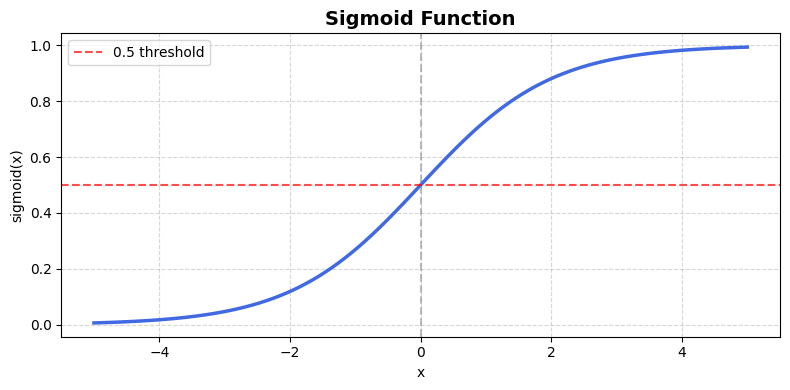


Logits: [2.  1.  0.5 3. ]
Softmax probabilities: [0.232 0.085 0.052 0.631]
Sum: 1.0


In [14]:
# ── Topic 15B: ML-relevant Math ──

# Sigmoid function (used in Logistic Regression, Neural Nets)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-5, 5, 100)
y = sigmoid(x)
print("Sigmoid output range:", f"{y.min():.3f} to {y.max():.3f}")
# Always between 0 and 1 (used for probability!)

plt.figure(figsize=(8, 4))
plt.plot(x, y, color='royalblue', linewidth=2.5)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='0.5 threshold')
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.title("Sigmoid Function", fontsize=14, fontweight='bold')
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print()

# Softmax (used in multi-class neural nets)
def softmax(x):
    e_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e_x / e_x.sum()

logits = np.array([2.0, 1.0, 0.5, 3.0])
probs = softmax(logits)
print("Logits:", logits)
print("Softmax probabilities:", probs.round(3))
print("Sum:", probs.sum().round(2))  # always sums to 1!

In [15]:
# ── Topic 15C: Normalization & Standardization ──

# Very important in Data Science!
# ML models work better with normalized data

data = np.array([10, 25, 5, 50, 30, 45, 15, 35, 20, 40], dtype=float)
print("Original data:", data)
print()

# Min-Max Normalization (scale to 0-1)
normalized = (data - data.min()) / (data.max() - data.min())
print("Min-Max Normalized (0 to 1):", normalized.round(3))
# min becomes 0, max becomes 1, rest in between

print()

# Standardization / Z-score (mean=0, std=1)
standardized = (data - data.mean()) / data.std()
print("Standardized (mean=0, std=1):", standardized.round(3))
print("Mean after:", standardized.mean().round(10))  # should be ~0
print("Std after:", standardized.std().round(3))      # should be 1

print()

# Vector Norm (used in ML distance calculations)
vec = np.array([3, 4])
L2_norm = np.linalg.norm(vec)
print("Vector:", vec)
print("L2 Norm (Euclidean distance from origin):", L2_norm)
# sqrt(3^2 + 4^2) = sqrt(9+16) = sqrt(25) = 5

print()
print("✅ Topic 15 Done!")
print("Key: sigmoid=0to1 | softmax=probabilities | normalize=0-1 | standardize=mean0-std1")

Original data: [10. 25.  5. 50. 30. 45. 15. 35. 20. 40.]

Min-Max Normalized (0 to 1): [0.111 0.444 0.    1.    0.556 0.889 0.222 0.667 0.333 0.778]

Standardized (mean=0, std=1): [-1.219 -0.174 -1.567  1.567  0.174  1.219 -0.87   0.522 -0.522  0.87 ]
Mean after: -0.0
Std after: 1.0

Vector: [3 4]
L2 Norm (Euclidean distance from origin): 5.0

✅ Topic 15 Done!
Key: sigmoid=0to1 | softmax=probabilities | normalize=0-1 | standardize=mean0-std1


---
# 📌 Topic 16 — NaN (Missing Data) Handling
**NaN = Not a Number = missing value**

In real Data Science projects, data is always messy.
NumPy has special functions to handle NaN without errors!


In [16]:
# ── Topic 16: NaN Operations ──

# Creating arrays with NaN
arr = np.array([1, 2, np.nan, 4, 5, np.nan, 7, 8])
print("Array with NaN:", arr)
print()

# Regular functions FAIL with NaN!
print("np.sum() with NaN:", np.sum(arr))    # returns nan!
print("np.mean() with NaN:", np.mean(arr))  # returns nan!

print()

# NaN-safe functions (ignores NaN!)
print("np.nansum():", np.nansum(arr))    # ignores nan
print("np.nanmean():", np.nanmean(arr))  # ignores nan
print("np.nanmax():", np.nanmax(arr))
print("np.nanmin():", np.nanmin(arr))
print("np.nanstd():", np.nanstd(arr).round(2))

print()

# Check where NaN is
print("Is NaN?", np.isnan(arr))
# [False False True False False True False False]

print("Number of NaN:", np.sum(np.isnan(arr)))
print("Number of valid:", np.sum(~np.isnan(arr)))

print()

# Remove NaN
clean = arr[~np.isnan(arr)]
print("After removing NaN:", clean)

# Replace NaN with mean
mean_val = np.nanmean(arr)
arr_filled = np.where(np.isnan(arr), mean_val, arr)
print(f"NaN replaced with mean ({mean_val:.1f}):", arr_filled)

print()
print("✅ Topic 16 Done!")
print("Key: np.nan | isnan() | nanmean/nansum/nanmax | replace with mean")

Array with NaN: [ 1.  2. nan  4.  5. nan  7.  8.]

np.sum() with NaN: nan
np.mean() with NaN: nan

np.nansum(): 27.0
np.nanmean(): 4.5
np.nanmax(): 8.0
np.nanmin(): 1.0
np.nanstd(): 2.5

Is NaN? [False False  True False False  True False False]
Number of NaN: 2
Number of valid: 6

After removing NaN: [1. 2. 4. 5. 7. 8.]
NaN replaced with mean (4.5): [1.  2.  4.5 4.  5.  4.5 7.  8. ]

✅ Topic 16 Done!
Key: np.nan | isnan() | nanmean/nansum/nanmax | replace with mean


---
# 📌 Topic 17 — Unique, Set Operations & Useful Functions
**These are very handy in Data Science for:**
- Finding unique categories
- Comparing two datasets
- Counting occurrences


In [17]:
# ── Topic 17A: Unique & Value Counts ──

arr = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5, 3, 1])
print("Array:", arr)
print()

# unique = find unique values
unique_vals = np.unique(arr)
print("Unique values:", unique_vals)

# unique with counts
unique_vals, counts = np.unique(arr, return_counts=True)
print("Unique values:", unique_vals)
print("Counts:", counts)
print()
print("Value frequency:")
for val, cnt in zip(unique_vals, counts):
    print(f"  {val} appears {cnt} times")

Array: [3 1 4 1 5 9 2 6 5 3 5 3 1]

Unique values: [1 2 3 4 5 6 9]
Unique values: [1 2 3 4 5 6 9]
Counts: [3 1 3 1 3 1 1]

Value frequency:
  1 appears 3 times
  2 appears 1 times
  3 appears 3 times
  4 appears 1 times
  5 appears 3 times
  6 appears 1 times
  9 appears 1 times


In [18]:
# ── Topic 17B: Set Operations ──

a = np.array([1, 2, 3, 4, 5, 6])
b = np.array([4, 5, 6, 7, 8, 9])
print("a:", a)
print("b:", b)
print()

# Union = all values from both (no duplicates)
print("Union:", np.union1d(a, b))

# Intersection = values in BOTH
print("Intersection:", np.intersect1d(a, b))

# Difference = in a but NOT in b
print("a - b (setdiff):", np.setdiff1d(a, b))

# in1d = check which elements of a are in b
print("Which elements of a are in b?", np.in1d(a, b))
# [False False False True True True]

print()

# Use case: find common students in two lists
class_A = np.array([101, 102, 103, 104, 105])
class_B = np.array([103, 105, 107, 109])
common = np.intersect1d(class_A, class_B)
print("Common students in both classes:", common)

print()
print("✅ Topic 17 Done!")
print("Key: unique() | return_counts | union1d | intersect1d | setdiff1d | in1d")

a: [1 2 3 4 5 6]
b: [4 5 6 7 8 9]

Union: [1 2 3 4 5 6 7 8 9]
Intersection: [4 5 6]
a - b (setdiff): [1 2 3]
Which elements of a are in b? [False False False  True  True  True]

Common students in both classes: [103 105]

✅ Topic 17 Done!
Key: unique() | return_counts | union1d | intersect1d | setdiff1d | in1d


/tmp/ipykernel_6425/1378350320.py:19: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  print("Which elements of a are in b?", np.in1d(a, b))


---
# 📌 Topic 18 — Performance Tips
**NumPy is fast ONLY if you use it correctly!**

**Vectorization** = doing operations on whole arrays (fast!)
**Loop** = doing operations one by one (slow!)

Always use NumPy functions instead of Python loops!


In [19]:
# ── Topic 18: Vectorization vs Loops ──

import time

data = np.random.randn(1_000_000)  # 1 million numbers
print("Array size:", len(data))
print()

# Method 1: Python loop (SLOW)
start = time.time()
result_loop = []
for x in data:
    result_loop.append(x ** 2)
time_loop = time.time() - start
print(f"Python loop time: {time_loop:.4f} seconds")

# Method 2: NumPy vectorized (FAST)
start = time.time()
result_numpy = data ** 2
time_numpy = time.time() - start
print(f"NumPy vectorized time: {time_numpy:.4f} seconds")

print()
speedup = time_loop / time_numpy
print(f"NumPy is {speedup:.0f}x FASTER than Python loop!")
print()

# More vectorization examples
arr = np.array([1, 2, 3, 4, 5])

# Instead of: [x*2 for x in arr]
print("❌ Slow (list comp):", [x*2 for x in arr])
print("✅ Fast (NumPy):", arr * 2)

# Instead of: sum([x for x in arr])
print("❌ Slow:", sum([x for x in arr]))
print("✅ Fast:", np.sum(arr))

print()
print("✅ Topic 18 Done!")
print("Key: ALWAYS use NumPy operations, never loops on arrays!")

Array size: 1000000

Python loop time: 0.2653 seconds
NumPy vectorized time: 0.0081 seconds

NumPy is 33x FASTER than Python loop!

❌ Slow (list comp): [np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
✅ Fast (NumPy): [ 2  4  6  8 10]
❌ Slow: 15
✅ Fast: 15

✅ Topic 18 Done!
Key: ALWAYS use NumPy operations, never loops on arrays!


---
# 📌 Topic 19 — Real Data Science Use Cases
**Putting it all together!**
These are actual patterns used in real Data Science projects.


In [21]:
# ── Topic 19A: Feature Scaling (ML Preprocessing) ──

# Before feeding data to ML model, always scale features!
np.random.seed(42)

# Raw features (different scales cause problems in ML)
age    = np.random.randint(18, 65, 100).astype(float)
salary = np.random.randint(20000, 100000, 100).astype(float)
score  = np.random.randint(0, 100, 100).astype(float)

print("Before scaling:")
print(f"Age:    min={age.min():.0f}, max={age.max():.0f}, mean={age.mean():.1f}")
print(f"Salary: min={salary.min():.0f}, max={salary.max():.0f}")
print(f"Score:  min={score.min():.0f}, max={score.max():.0f}")

print()

# Stack into feature matrix
X = np.column_stack([age, salary, score])
print("Feature matrix shape:", X.shape)  # (100, 3)

# Min-Max scaling for each column
X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
print("After Min-Max scaling:")
print(f"All values between: {X_scaled.min():.3f} and {X_scaled.max():.3f}")
print("Scaled (first 5 rows):")
print(X_scaled[:5].round(3))

Before scaling:
Age:    min=18, max=64, mean=40.9
Salary: min=20206, max=99575
Score:  min=0, max=99

Feature matrix shape: (100, 3)
After Min-Max scaling:
All values between: 0.000 and 1.000
Scaled (first 5 rows):
[[0.826 0.031 0.232]
 [0.609 0.605 0.687]
 [0.304 0.064 0.98 ]
 [0.913 0.495 0.697]
 [0.152 0.415 0.859]]


In [22]:
# ── Topic 19B: Distance Calculation ──

# Euclidean distance (used in KNN algorithm!)
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# 3 customers with features: [age, income, spending_score]
customers = np.array([
    [25, 50000, 70],
    [45, 80000, 40],
    [30, 60000, 85]
])

# Find distance between customer 0 and customer 1
d01 = euclidean_distance(customers[0], customers[1])
d02 = euclidean_distance(customers[0], customers[2])
print(f"Distance between Customer 0 and 1: {d01:.2f}")
print(f"Distance between Customer 0 and 2: {d02:.2f}")
print(f"Customer 0 is closer to Customer {'1' if d01 < d02 else '2'}!")

print()

# Cosine similarity (used in NLP!)
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

vec1 = np.array([1, 2, 3])
vec2 = np.array([4, 5, 6])
vec3 = np.array([-1, -2, -3])  # opposite direction

print(f"Similarity(vec1, vec2): {cosine_similarity(vec1, vec2):.3f}")  # ~1 (similar)
print(f"Similarity(vec1, vec3): {cosine_similarity(vec1, vec3):.3f}")  # -1 (opposite)

Distance between Customer 0 and 1: 30000.02
Distance between Customer 0 and 2: 10000.01
Customer 0 is closer to Customer 2!

Similarity(vec1, vec2): 0.975
Similarity(vec1, vec3): -1.000


Data generated: y = 3x + 10 + noise

Calculated: slope=2.884, intercept=10.129
Expected:   slope=3.000, intercept=10.000
MSE: 3.301


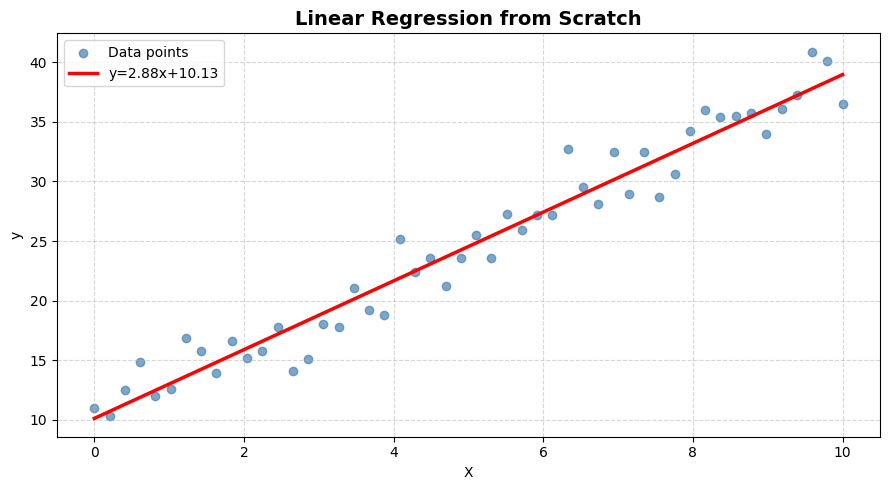

In [23]:
# ── Topic 19C: Simple Linear Regression from Scratch ──

# This is what sklearn does under the hood!
np.random.seed(42)

# Generate data: y = 3x + 10 + noise
X = np.linspace(0, 10, 50)
noise = np.random.randn(50) * 2
y = 3 * X + 10 + noise

print("Data generated: y = 3x + 10 + noise")
print()

# Calculate slope (m) and intercept (b) manually
# Using Normal Equation: β = (X'X)^-1 X'y
X_b = np.column_stack([np.ones(len(X)), X])
# Add column of ones for intercept

params = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)
intercept, slope = params[0], params[1]
print(f"Calculated: slope={slope:.3f}, intercept={intercept:.3f}")
print(f"Expected:   slope=3.000, intercept=10.000")

# Predictions
y_pred = slope * X + intercept

# MSE (Mean Squared Error)
mse = np.mean((y - y_pred) ** 2)
print(f"MSE: {mse:.3f}")

# Plot
plt.figure(figsize=(9, 5))
plt.scatter(X, y, color='steelblue', alpha=0.7, label='Data points')
plt.plot(X, y_pred, color='red', linewidth=2.5, label=f'y={slope:.2f}x+{intercept:.2f}')
plt.title("Linear Regression from Scratch", fontsize=14, fontweight='bold')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
# 📌 Topic 20 — Interview Questions & Tricks
**Most asked NumPy interview questions for Data Science roles!**


In [27]:
# ── Topic 20: Interview Questions ──

print("=" * 50)
print("TOP NUMPY INTERVIEW QUESTIONS")
print("=" * 50)

# Q1: Difference between list and numpy array?
print("Q1: List vs NumPy Array")
lst = [1, 2, 3]
arr = np.array([1, 2, 3])
print("List * 2:", lst * 2)    # [1,2,3,1,2,3] (repeats!)
print("Array * 2:", arr * 2)   # [2,4,6] (multiplies each!)

print()

# Q2: What is broadcasting?
print("Q2: Broadcasting example")
a = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([10, 20, 30])
print("(2x3) + (3,) =")
print(a + b)  # b added to each row

print()

# Q3: View vs Copy
print("Q3: View vs Copy")
original = np.array([1, 2, 3, 4, 5])
view = original[1:4]      # view - connected
copy = original[1:4].copy()  # copy - independent
view[0] = 99
print("After changing view[0]=99:")
print("Original:", original)  # changed!
print("Copy:", copy)           # not changed!

print()

# Q4: How to find unique values and their counts?
print("Q4: Unique + Counts")
arr = np.array([1, 2, 2, 3, 3, 3, 4, 4, 4, 4])
vals, cnts = np.unique(arr, return_counts=True)
print(dict(zip(vals, cnts)))

print()

# Q5: Flatten a 2D array
print("Q5: Flatten 2D to 1D")
arr2d = np.array([[1,2,3],[4,5,6]])
print("flatten:", arr2d.flatten())
print("reshape(-1):", arr2d.reshape(-1))
print("ravel:", arr2d.ravel())

print()

# Q6: How to normalize an array?
print("Q6: Normalize to 0-1")
data = np.array([10, 25, 5, 50, 30])
normalized = (data - data.min()) / (data.max() - data.min())
print("Normalized:", normalized.round(3))

print()

# Q7: Difference between axis=0 and axis=1?
print("Q7: axis=0 vs axis=1")
arr = np.array([[1,2,3],[4,5,6]])
print("Array:", arr)
print("sum axis=0 (column-wise):", np.sum(arr, axis=0))  # [5,7,9]
print("sum axis=1 (row-wise):", np.sum(arr, axis=1))     # [6,15]

print()
print("✅ Topic 20 Done!")

TOP NUMPY INTERVIEW QUESTIONS
Q1: List vs NumPy Array
List * 2: [1, 2, 3, 1, 2, 3]
Array * 2: [2 4 6]

Q2: Broadcasting example
(2x3) + (3,) =
[[11 22 33]
 [14 25 36]]

Q3: View vs Copy
After changing view[0]=99:
Original: [ 1 99  3  4  5]
Copy: [2 3 4]

Q4: Unique + Counts
{np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}

Q5: Flatten 2D to 1D
flatten: [1 2 3 4 5 6]
reshape(-1): [1 2 3 4 5 6]
ravel: [1 2 3 4 5 6]

Q6: Normalize to 0-1
Normalized: [0.111 0.444 0.    1.    0.556]

Q7: axis=0 vs axis=1
Array: [[1 2 3]
 [4 5 6]]
sum axis=0 (column-wise): [5 7 9]
sum axis=1 (row-wise): [ 6 15]

✅ Topic 20 Done!


---
#  Complete NumPy Revision Summary

## Part 2 Topics

| Topic | Key Functions | Used In |
|-------|--------------|---------|
| Statistics | `mean, median, std, percentile, IQR` | EDA |
| Random | `normal, uniform, choice, shuffle` | Testing, Augmentation |
| Linear Algebra | `@, .T, linalg.inv/eig/solve` | ML algorithms |
| Advanced Indexing | `np.where, np.clip, boolean mask` | Data cleaning |
| Math Functions | `sigmoid, softmax, normalize` | ML preprocessing |
| NaN Handling | `isnan, nanmean, nansum` | Real data cleaning |
| Set Operations | `unique, union1d, intersect1d` | Feature engineering |
| Performance | Vectorization over loops | Production code |
| Use Cases | Scaling, distance, regression | Real projects |

---

## ⚡ Must-Know One-Liners
```python
# Statistics
np.percentile(arr, [25, 50, 75])      # Q1, Q2, Q3
Q3 - Q1                               # IQR
arr[(arr < Q1-1.5*IQR) | (arr > Q3+1.5*IQR)]  # outliers

# NaN safe
np.nanmean(arr)                        # mean ignoring NaN
arr[~np.isnan(arr)]                   # remove NaN

# ML
(X - X.min()) / (X.max() - X.min())  # normalize 0-1
(X - X.mean()) / X.std()             # standardize
1 / (1 + np.exp(-x))                 # sigmoid
np.linalg.norm(vec)                   # L2 norm

# Useful
np.unique(arr, return_counts=True)    # value counts
np.where(arr > 50, "High", "Low")    # replace values
np.clip(arr, 0, 100)                 # cap values
np.column_stack([a, b, c])           # make feature matrix
```